Running simulation for Order k=4...


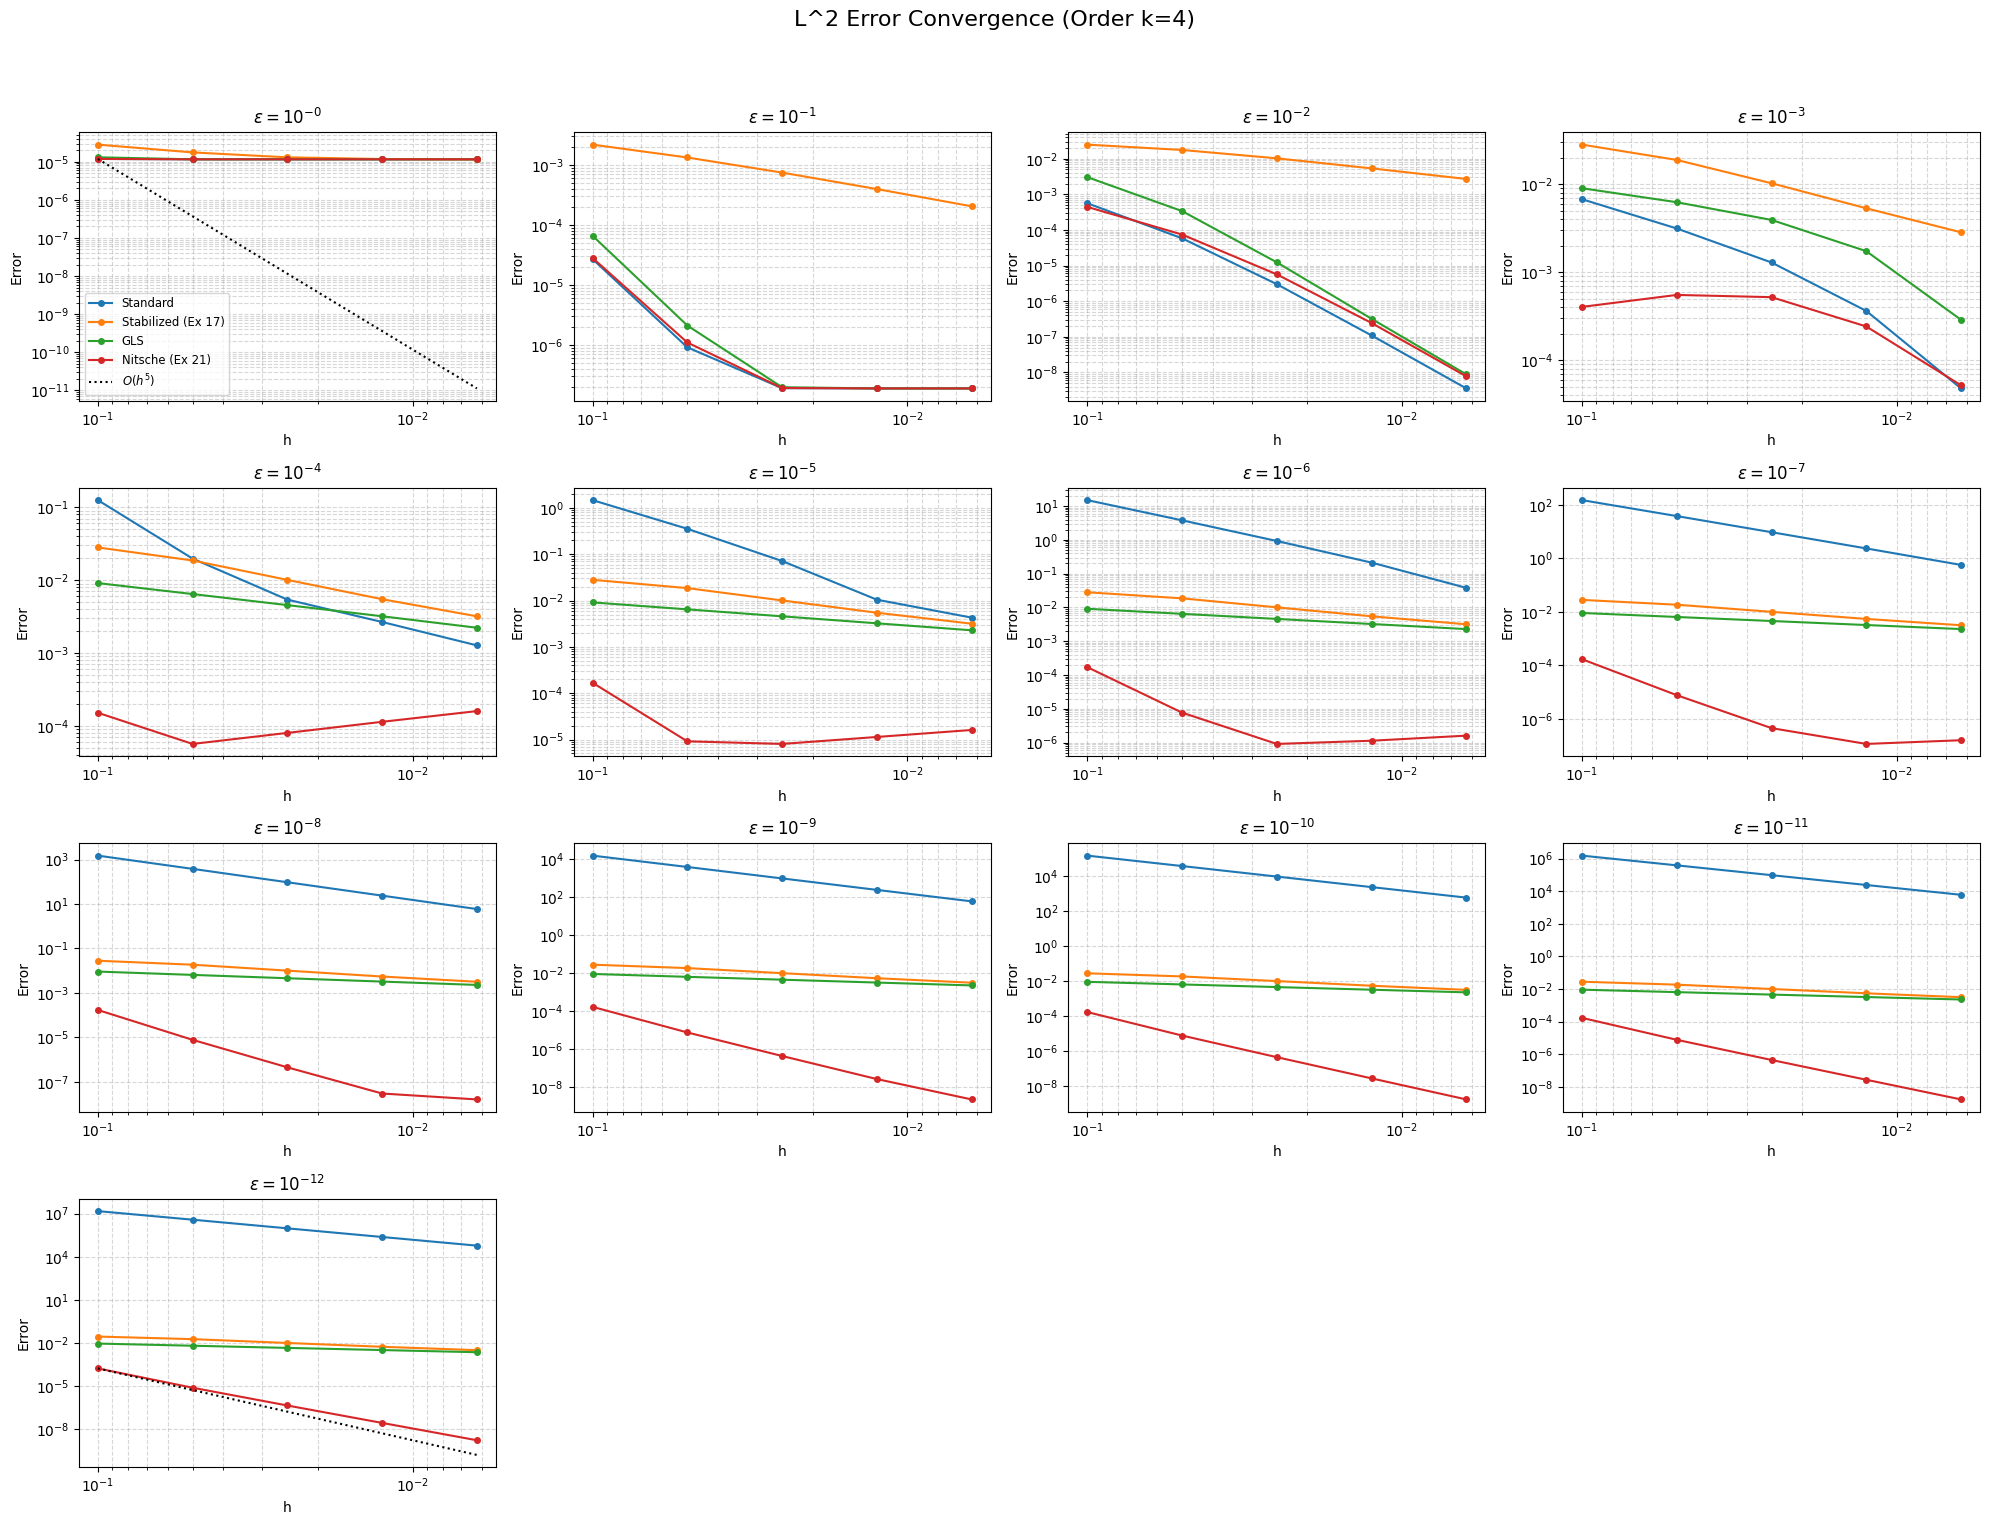

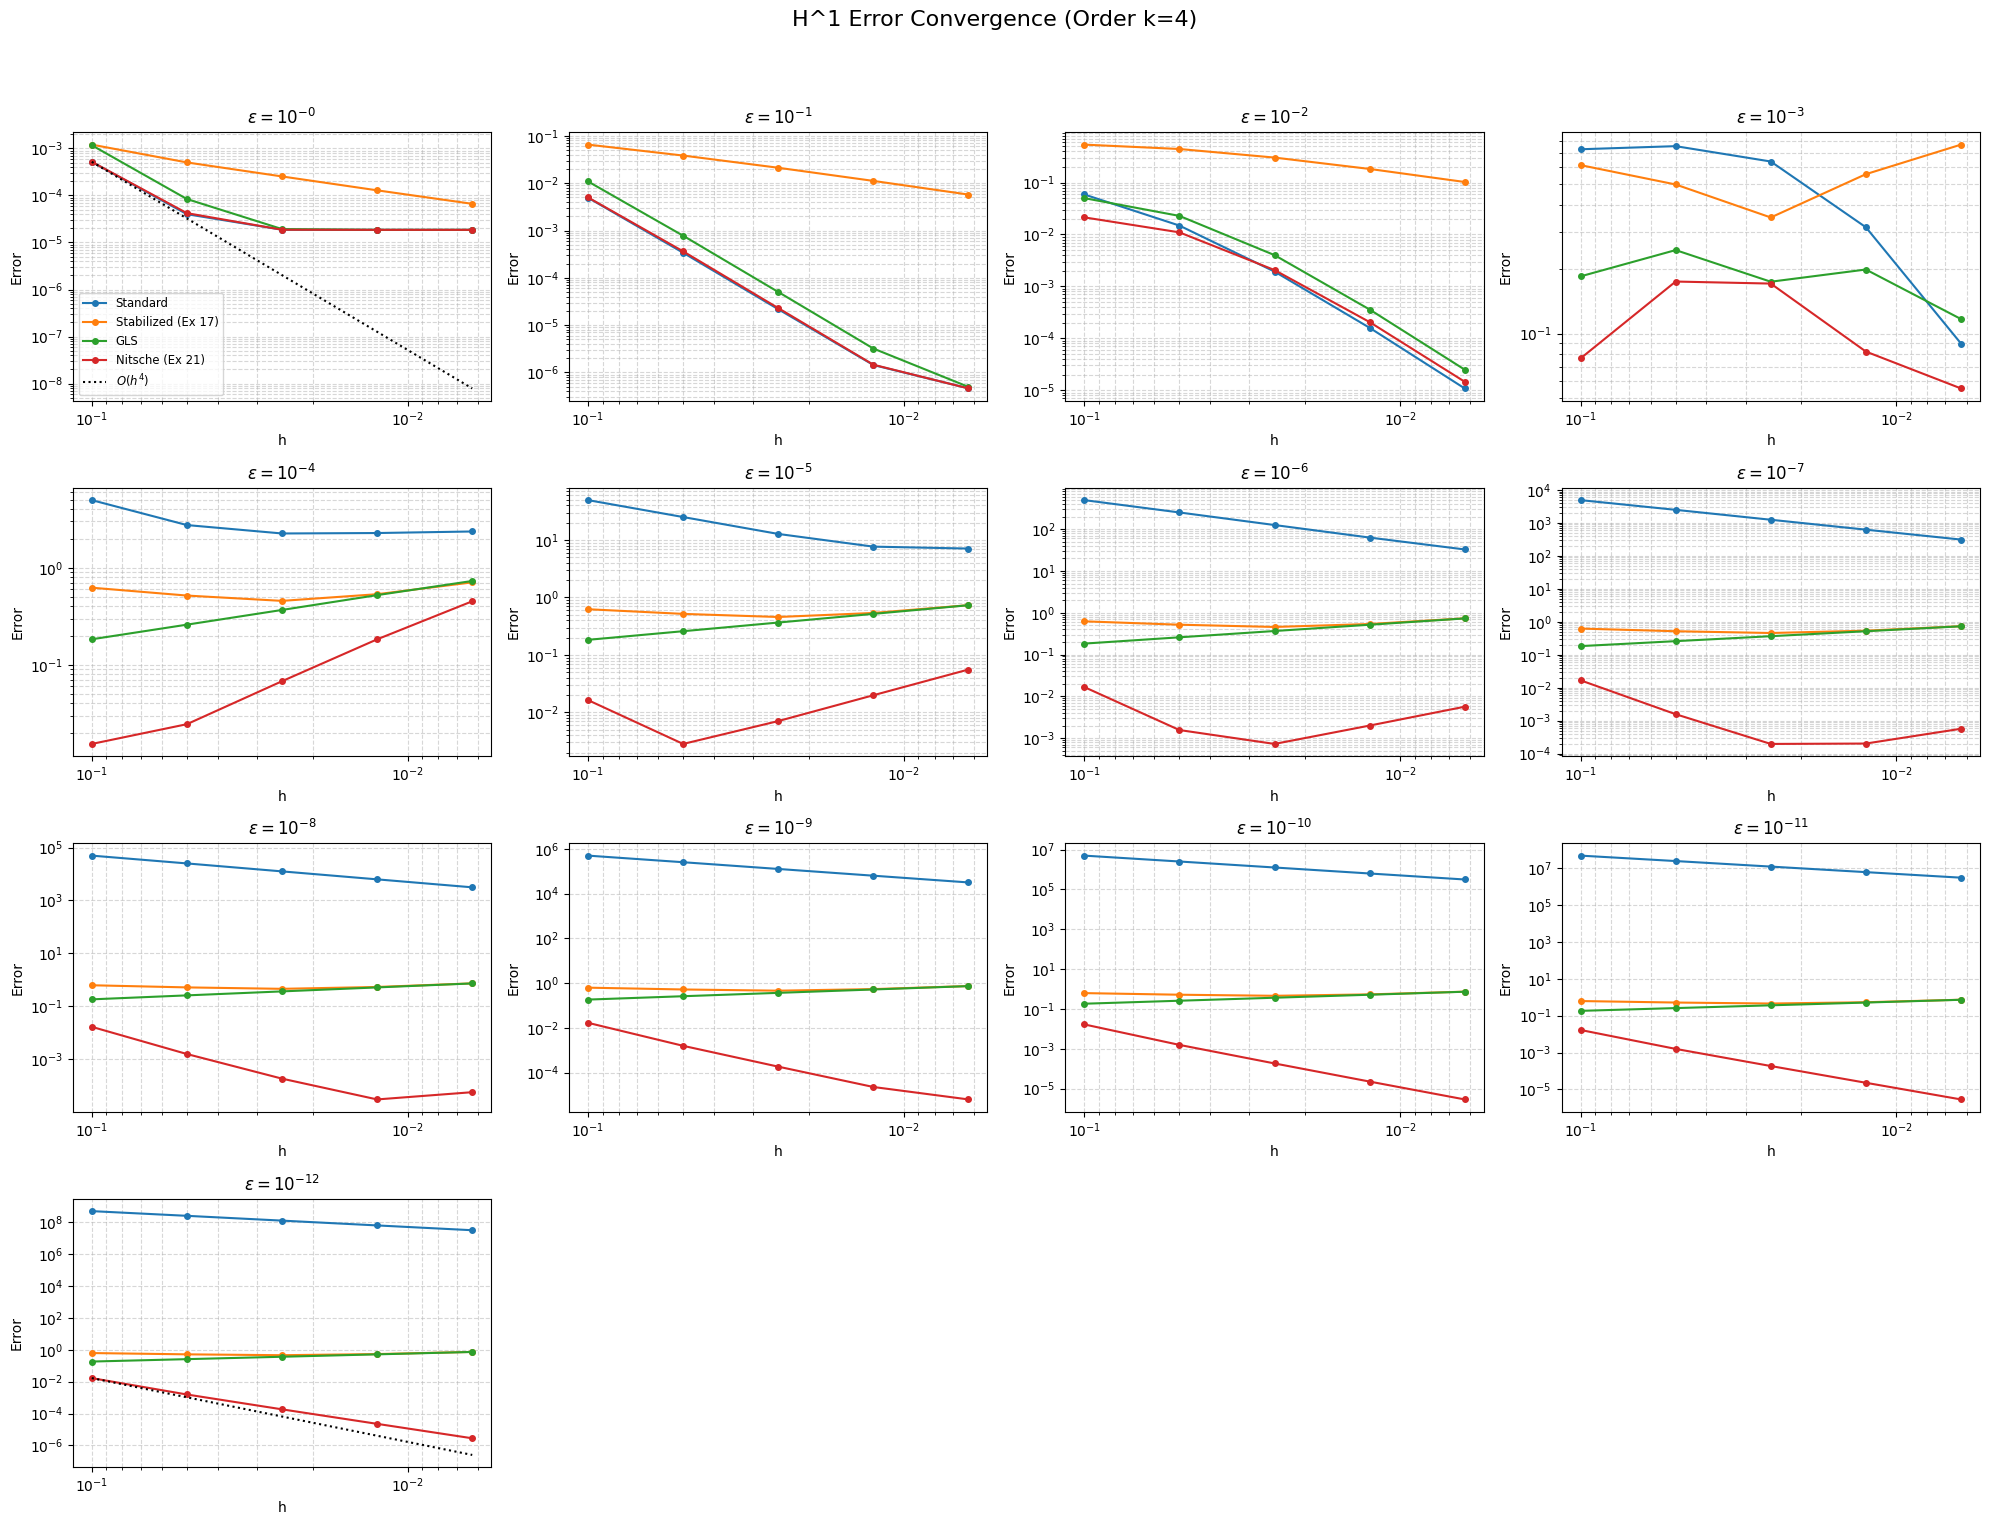

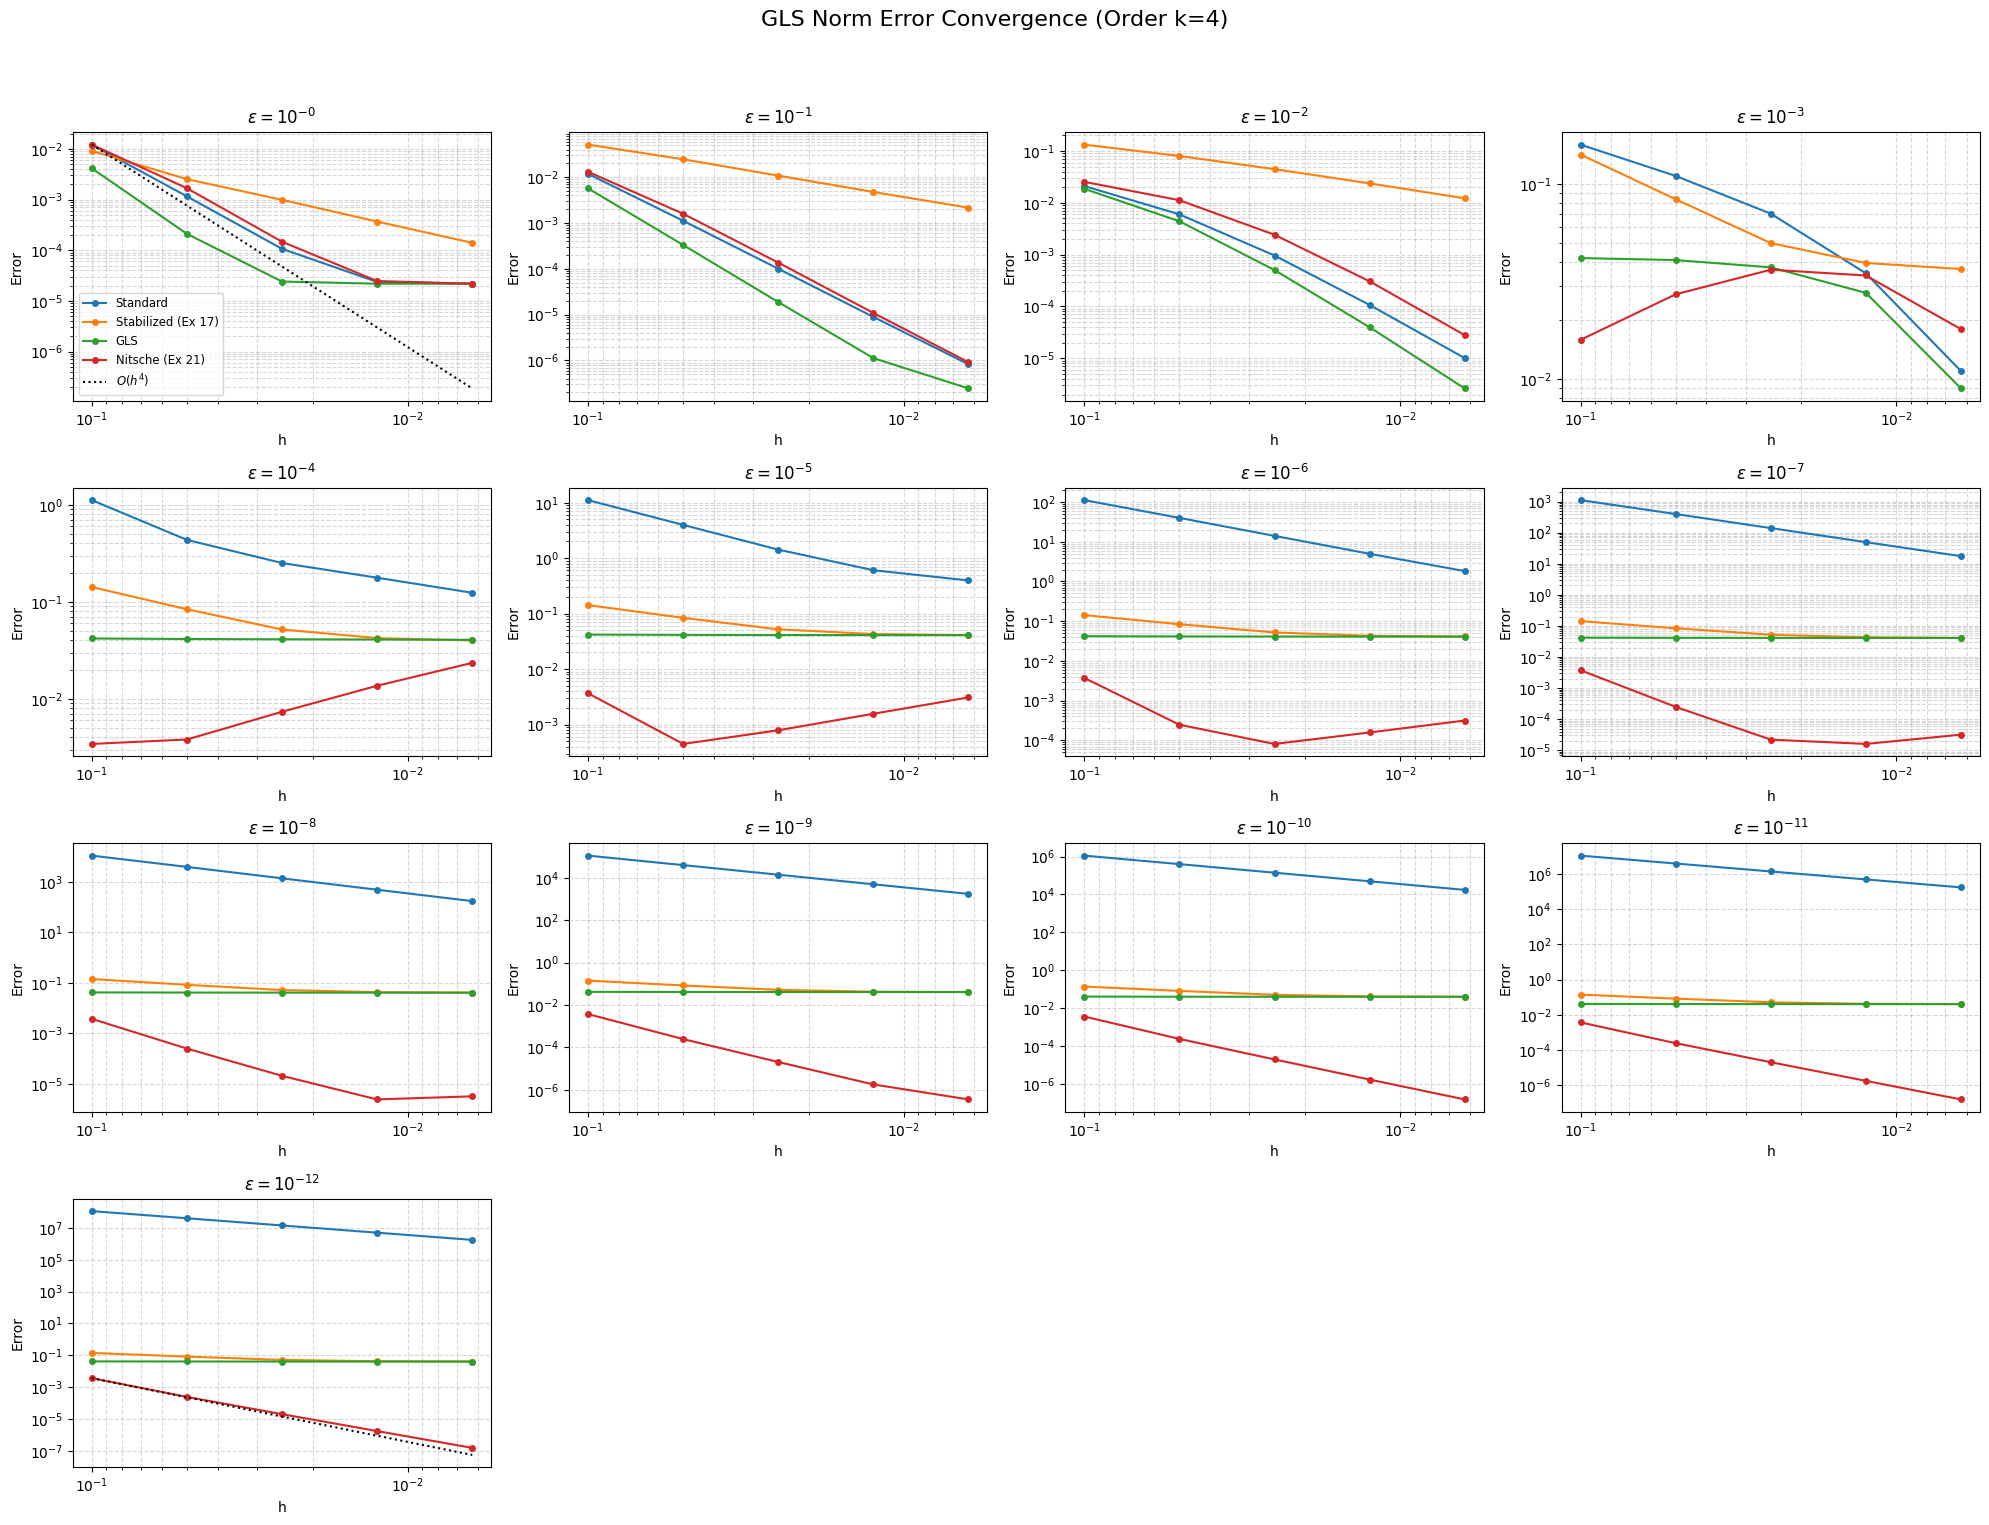

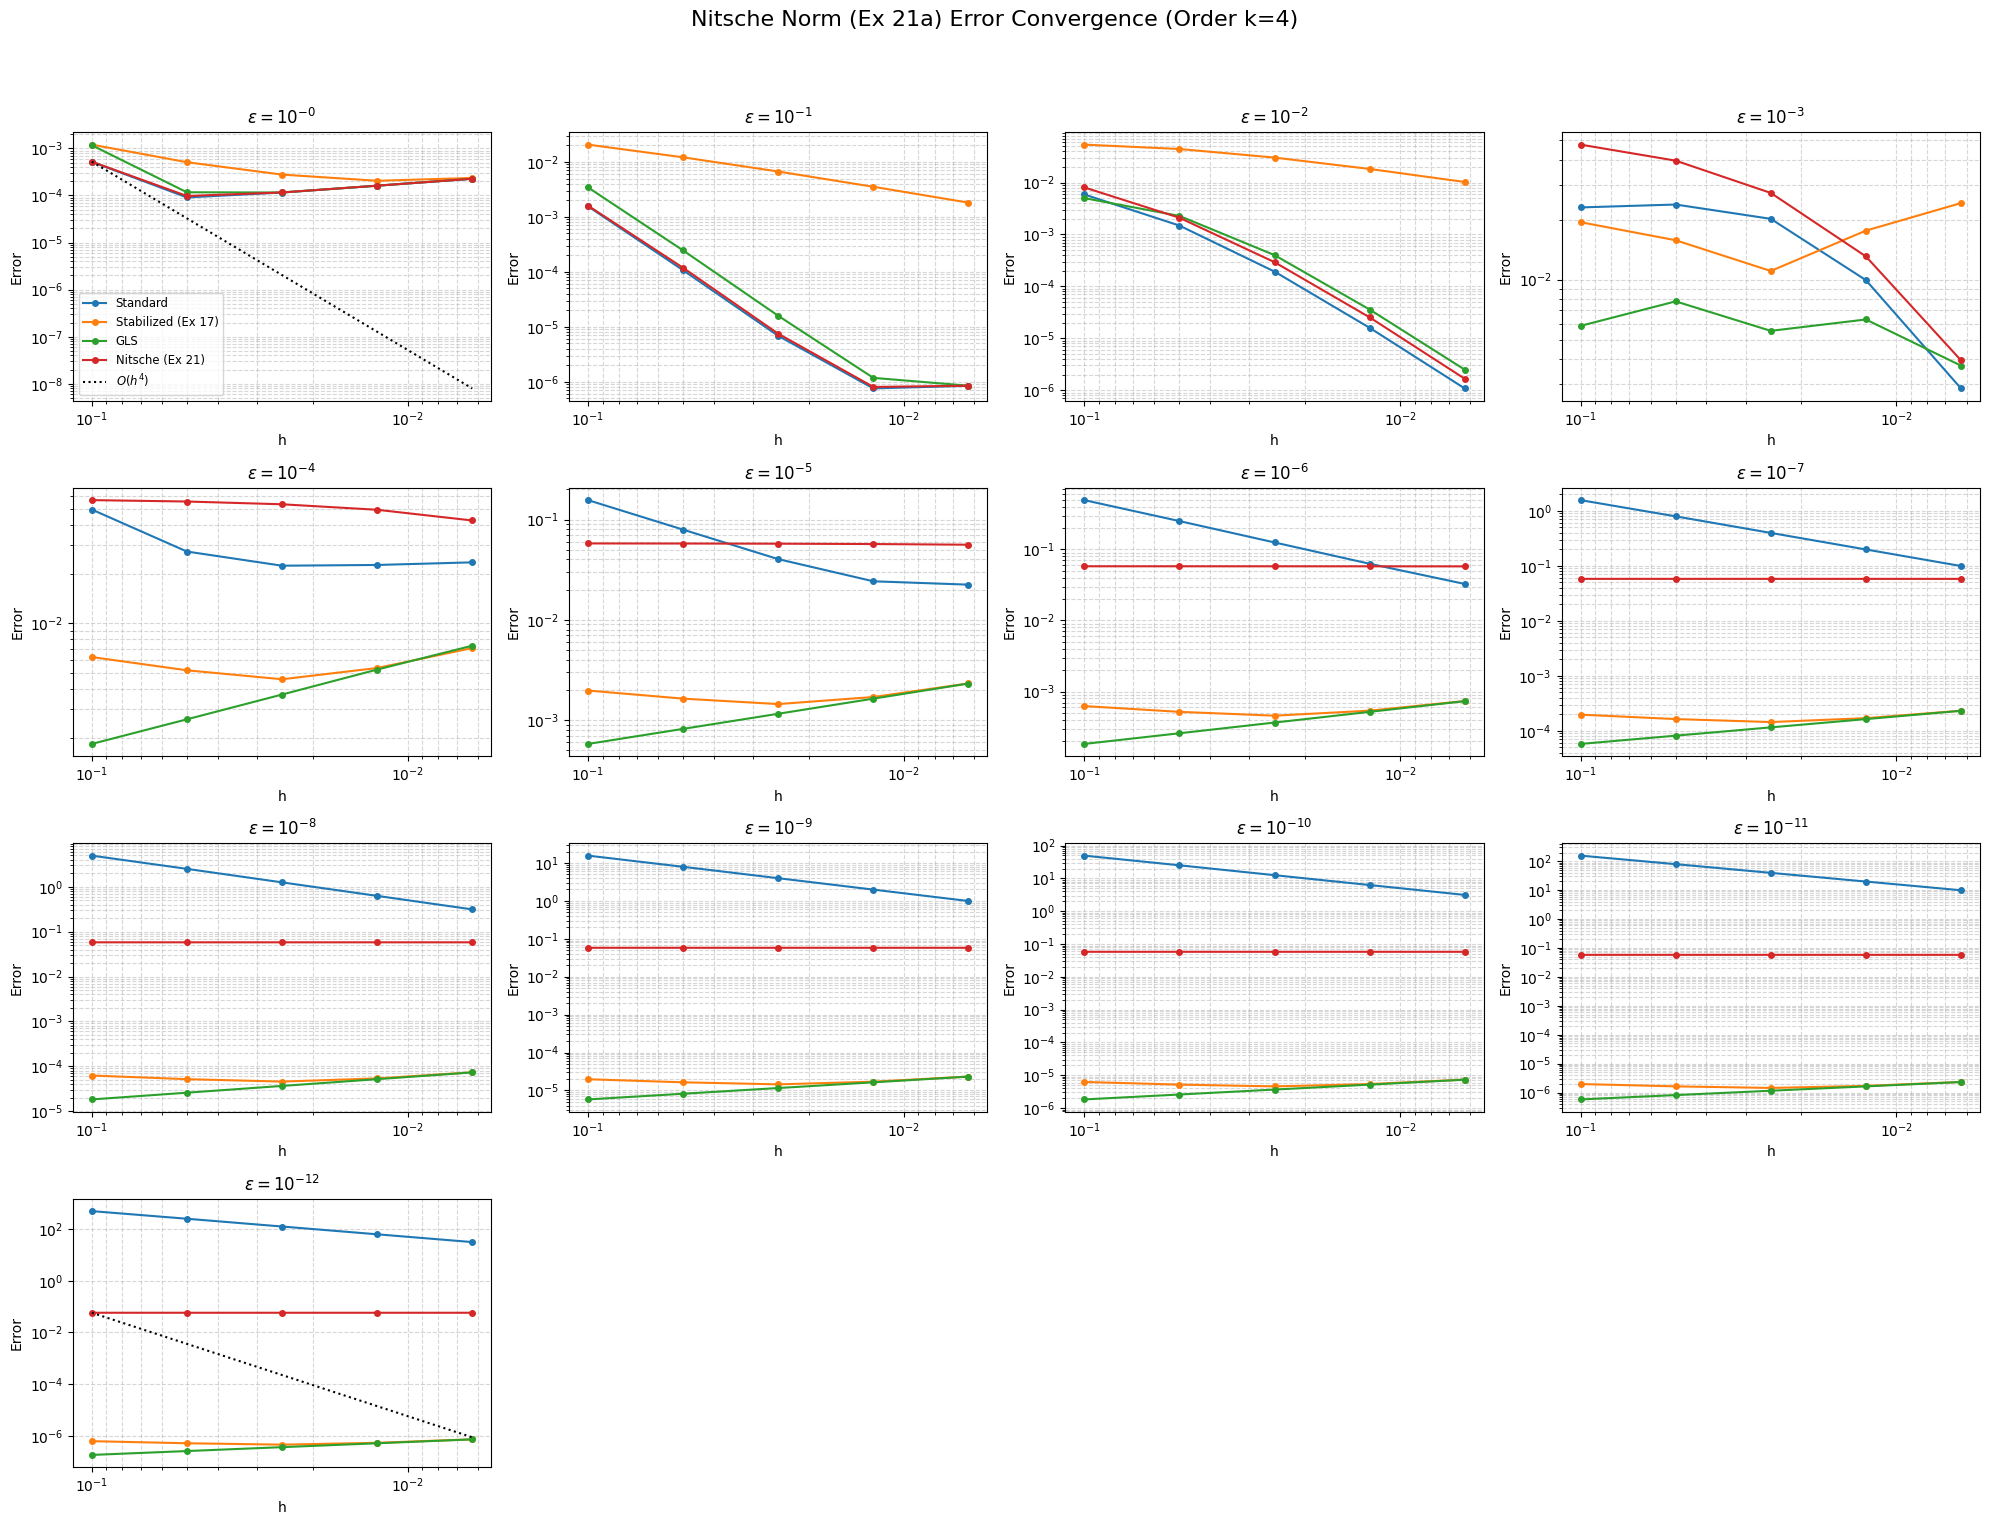

In [10]:
from ngsolve import *
from ngsolve.meshes import Make1DMesh
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Exact Solution Definition
# ------------------------------------------------------------------------------
def ExactSolution(eps):
    K = 11 * np.pi
    denom = 1 + (eps * K)**2
    A = eps / denom
    B = -1 / (K * denom)
    
    # Stable calculation for boundary layer term (x is NGSolve CF)
    # We use exp((x-1)/eps). Since x <= 1, the exponent is negative.
    exp_term = exp( (x-1)/eps )
    term_homog = -B + 2*B * exp_term 
    
    u_exact = term_homog + A * sin(K*x) + B * cos(K*x)
    return u_exact

# ------------------------------------------------------------------------------
# 2. Solver Implementation
# ------------------------------------------------------------------------------
def SolveAdvectionDiffusion(epsilon, N, order, method):
    # 1D Mesh on [0, 1]
    mesh = Make1DMesh(N)
    h = 1.0 / N
    
    # Finite Element Space
    # Nitsche uses WEAK boundary conditions, so no "dirichlet" flag!
    if method == "Nitsche (Ex 21)":
        fes = H1(mesh, order=order)
    else:
        fes = H1(mesh, order=order, dirichlet="left|right")

    u, v = fes.TnT()
    
    beta_vec = 1.0 
    f_source = sin(11 * np.pi * x)
    n = specialcf.normal(mesh.dim)
    
    # --- Standard Forms ---
    a = BilinearForm(fes)
    f = LinearForm(fes)
    
    # Volume Terms (Common to all)
    # Note: grad(u)[0] extracts scalar derivative in 1D
    a += (epsilon * grad(u)[0] * grad(v)[0] + beta_vec * grad(u)[0] * v) * dx
    f += f_source * v * dx
    
    # --- METHOD SPECIFIC TERMS ---
    
    if method == "Stabilized (Ex 17)":
        # Simple Artificial Diffusion
        art_diff = 0.5 * h 
        a += art_diff * grad(u)[0] * grad(v)[0] * dx

    elif method == "GLS":
        # Tau parameter
        tau = h / (2 * abs(beta_vec))
        
        # Hessian for second derivative u_xx
        u_xx = u.Operator("hesse")[0]
        v_xx = v.Operator("hesse")[0]
        
        # Strong form operators: L(u) = -eps*u'' + beta*u'
        Lu = -epsilon * u_xx + beta_vec * grad(u)[0]
        Lv = -epsilon * v_xx + beta_vec * grad(v)[0]
        
        a += tau * Lu * Lv * dx
        f += tau * f_source * Lv * dx

    elif method == "Nitsche (Ex 21)":
        gamma = 20.0 # Penalty parameter (must be large enough)
        
        # 1. Consistency & Symmetry Terms (Boundary)
        # Using ds(skeleton=True) as per hint
        # Term: - eps * (n * grad(u)) * v
        # In 1D, n is +/- 1 at boundaries. grad(u) is vector, n*grad(u) is normal derivative.
        # We write explicitly: (grad(u)[0] * n[0])
        normal_deriv_u = grad(u)[0] * n[0]
        normal_deriv_v = grad(v)[0] * n[0]
        
        a += -epsilon * normal_deriv_u * v * ds(skeleton=True)
        a += -epsilon * u * normal_deriv_v * ds(skeleton=True)
        
        # 2. Penalty Term
        # Term: + (eps * gamma / h) * u * v
        a += (epsilon * gamma / h) * u * v * ds(skeleton=True)
        
        # 3. Inflow Stabilization
        # Term: - integral_{Gamma_in} (beta.n) * u * v
        # In 1D with beta=1: 
        #   x=0 is Inflow (n=-1, beta.n = -1 < 0)
        #   x=1 is Outflow (n=+1, beta.n = +1 > 0)
        # We use IfPos(beta*n, 0, beta*n) to select inflow.
        beta_n = beta_vec * n[0]
        a += -IfPos(beta_n, 0, beta_n) * u * v * ds(skeleton=True)
        
        # --- RHS Consistency Terms (since u is not 0 everywhere) ---
        # The problem in Ex 21 assumes u=g on boundary. 
        # For this specific exact solution, u(0)=0 and u(1)=0.
        # So g=0, and these RHS terms vanish. 
        # However, for completeness, we add them assuming g=0.
        g = 0.0 
        f += -epsilon * g * normal_deriv_v * ds(skeleton=True)
        f += (epsilon * gamma / h) * g * v * ds(skeleton=True)
        f += -IfPos(beta_n, 0, beta_n) * g * v * ds(skeleton=True)

    a.Assemble()
    f.Assemble()
    
    gfu = GridFunction(fes)
    gfu.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec
    
    return gfu, mesh


# ------------------------------------------------------------------------------
# 3. Simulation & Data Collection
# ------------------------------------------------------------------------------

# Setup
epsilons = [10**(-i) for i in range(13)] # 1 to 10^-12
methods = ["Standard", "Stabilized (Ex 17)", "GLS", "Nitsche (Ex 21)"]
mesh_sizes = [10, 20, 40, 80, 160] # Mesh N
rate = 4 # Polynomial Order

# Storage
results_L2 = {eps: {m: [] for m in methods} for eps in epsilons}
results_H1 = {eps: {m: [] for m in methods} for eps in epsilons}
results_GLS_Norm = {eps: {m: [] for m in methods} for eps in epsilons}
results_Nitsche_Norm = {eps: {m: [] for m in methods} for eps in epsilons}

print(f"Running simulation for Order k={rate}...")

for eps in epsilons:
    for m in methods:
        errs_l2 = []
        errs_h1 = []
        errs_gls = []
        errs_nitsche = []
        
        for N in mesh_sizes:
            try:
                gfu, mesh = SolveAdvectionDiffusion(eps, N, rate, m)
                u_ex = ExactSolution(eps)
                h_val = 1.0/N
                
                # --- 1. L2 Error ---
                diff = gfu - u_ex
                l2_sq = Integrate(diff**2, mesh)
                errs_l2.append(sqrt(l2_sq))
                
                # --- 2. H1 Semi-Norm Error ---
                # Exact gradient
                grad_u_ex = u_ex.Diff(x)
                diff_grad = grad(gfu)[0] - grad_u_ex
                h1_sq = Integrate(diff_grad**2, mesh)
                errs_h1.append(sqrt(h1_sq))
                
                # --- 3. GLS Norm (Ex 20d) ---
                # ||v||_GLS^2 = L2^2 + eps*H1^2 + sum tau*||Res||^2
                beta = 1.0
                tau = h_val / (2*beta)
                
                # Residual = f - (-eps*u_xx + beta*u_x)
                u_h_xx = gfu.Operator("hesse")[0]
                u_h_x = grad(gfu)[0]
                f_val = sin(11 * np.pi * x)
                residual = f_val - (-eps * u_h_xx + beta * u_h_x)
                res_sq = Integrate(tau * residual**2, mesh)
                
                gls_sq = l2_sq + eps * h1_sq + res_sq
                errs_gls.append(sqrt(gls_sq))

                # --- 4. Nitsche Norm (Ex 21a) ---
                # ||v||_Nit^2 = eps*H1^2 + (eps/h)*||v||_dO^2 + || |beta.n|^0.5 v ||_dO^2
                # In 1D, boundary integral is sum of values at x=0,1
                
                # Boundary term weight: (eps/h + |beta.n|)
                # |beta.n| is 1.0 at both ends
                weight = (eps / h_val) + 1.0
                
                # Error at boundaries
                err_0 = gfu(mesh(0)) - u_ex(mesh(0))
                err_1 = gfu(mesh(1)) - u_ex(mesh(1))
                boundary_term = weight * (err_0**2 + err_1**2)
                
                nitsche_sq = eps * h1_sq + boundary_term
                errs_nitsche.append(sqrt(nitsche_sq))
                
            except Exception as e:
                #print(f"Error in {m}, eps={eps}: {e}")
                errs_l2.append(float('nan'))
                errs_h1.append(float('nan'))
                errs_gls.append(float('nan'))
                errs_nitsche.append(float('nan'))
        
        results_L2[eps][m] = errs_l2
        results_H1[eps][m] = errs_h1
        results_GLS_Norm[eps][m] = errs_gls
        results_Nitsche_Norm[eps][m] = errs_nitsche

# ------------------------------------------------------------------------------
# 4. Plotting Function
# ------------------------------------------------------------------------------

def PlotGrid(results_dict, norm_name, ref_order):
    rows = 4
    cols = 4
    fig, axs = plt.subplots(rows, cols, figsize=(20, 16))
    fig.suptitle(f"{norm_name} Error Convergence (Order k={rate})", fontsize=16)
    
    axs_flat = axs.flatten()
    h_values = [1/N for N in mesh_sizes]

    for i, eps in enumerate(epsilons):
        ax = axs_flat[i]
        
        for m in methods:
            errs = results_dict[eps][m]
            if not all(np.isnan(errs)):
                ax.loglog(h_values, errs, 'o-', label=m, markersize=4)
        
        ax.set_title(f"$\epsilon = 10^{{-{i}}}$")
        ax.set_xlabel("h")
        ax.set_ylabel(f"Error")
        ax.grid(True, which="both", linestyle='--', alpha=0.5)
        ax.invert_xaxis() # h decreases to right
        
        # Reference Line
        if i == 0 or i == 12:
            ref = [errs[0] * (h/h_values[0])**ref_order for h in h_values]
            ax.loglog(h_values, ref, 'k:', label=f'$O(h^{{{ref_order}}})$')
        
        if i == 0:
            ax.legend(loc='lower left', fontsize='small')

    for j in range(len(epsilons), rows*cols):
        axs_flat[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ------------------------------------------------------------------------------
# 5. Generate All Plots
# ------------------------------------------------------------------------------

# 1. L2 Error
PlotGrid(results_L2, "L^2", rate + 1)

# 2. H1 Error
PlotGrid(results_H1, "H^1", rate)

# 3. GLS Norm (Ex 20d)
PlotGrid(results_GLS_Norm, "GLS Norm", rate)

# 4. Nitsche Norm (Ex 21a)
PlotGrid(results_Nitsche_Norm, "Nitsche Norm (Ex 21a)", rate)